# mamba_va (CompSSM) — local eval monitor

Run this on the **laptop** while Colab trains `train_mamba_va_nocond.ipynb`.
Reads checkpoints, `hparams.json`, and the CSV metrics log from the Google
Drive-synced `mamba_va_runs/` folder. The modelling target here is the **wet
audio itself** (direct dry→wet), so the eval compares **input vs output audio**
— waveform overlay, error, compression scatter, ESR, and listenable audio —
*not* gain-reduction curves (that is `03_initial_GR_pred/eval_lstm.ipynb`).

1. List all `CompSSM` runs + their checkpoints
2. Plot train-vs-val loss from `metrics.csv`
3. Stream any checkpoint over validation songs → waveform / scatter / listen
4. Excerpt-based validation audio metrics (ESR, MR-STFT, …)

No Colab resources are used — purely reads files synced by Google Drive.

> Note: since mamba_va v0.2 the level detector runs through the parallel scan
> (no per-sample loop), so CPU/MPS streaming is fast; excerpts are still used
> to keep the monitor snappy.

> Sanity floor: a constant ≈ −10 dB gain scores ESR ≈ 0.075/0.090 on the val
> songs (Borderline / NosPalpitants) — a checkpoint has only learned dynamics
> once it is clearly below that.

> Requirements: `uv sync` at repo root.

> ⚠ Checkpoints trained with mamba_va **v0.1** (runs before 2026-06-10) use a
> different detector parameterisation and will not load into v0.2 code.

In [1]:
# ── 0. Imports and defaults ─────────────────────────────────────────
import os, sys, glob, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import torch

warnings.filterwarnings("ignore", category=UserWarning)

# Reuse the GR-eval helpers (run listing, pairing, split, metric aggregation).
_HELPERS_DIR = Path.cwd().parent / "03_initial_GR_pred"
assert (_HELPERS_DIR / "eval_helpers.py").is_file(), f"eval_helpers not at {_HELPERS_DIR}"
sys.path.insert(0, str(_HELPERS_DIR))
from eval_helpers import (
    _checkpoint_sort_key, latest_best_checkpoint, list_runs, plot_loss_curves,
    _find_hparams_json, same_setting_pairs, _read_dry_wet_segment,
    _pair_num_frames, _song_from_dry_path, _validation_pairs_from_training_split,
    _weighted_average_metric_rows,
)

# Make the mamba_va package importable (local source tree, not a pip package).
def _local_pkg_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for c in (base / "mamba_va", base / "04_s6_ssm" / "mamba_va"):
            if (c / "mamba_va" / "__init__.py").is_file():
                return c
    return None

_pkg_root = _local_pkg_root()
assert _pkg_root, "mamba_va package not found under the repo."
sys.path.insert(0, str(_pkg_root))
import mamba_va
from mamba_va import CompSSM
from mamba_va.losses import esr as esr_loss

from src.losses import compute_all_losses as compute_audio_losses

DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp"
RUNS_DIR  = "/Volumes/Saola's Drive/AllCode/thesis/data/mamba_va_runs"

SAMPLE_RATE = 44100
DEVICE = "cpu"   # custom scan/detector are torch-native; 'mps' also works

print(f"torch {torch.__version__}  |  device: {DEVICE}")
print(f"mamba_va {mamba_va.__version__} from {Path(mamba_va.__file__).parent}")

torch 2.10.0  |  device: cpu
mamba_va 0.1.0 from /Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/04_s6_ssm/mamba_va/mamba_va


In [2]:
# ── 1. List available CompSSM runs ──────────────────────────────────
assert RUNS_DIR and os.path.isdir(RUNS_DIR), f"RUNS_DIR not found: {RUNS_DIR}"

runs_df = list_runs(RUNS_DIR)
assert not runs_df.empty, "No runs found yet."

available_models_df = runs_df[runs_df["type"].str.contains("CompSSM", na=False)].copy()
assert not available_models_df.empty, "No CompSSM (mamba_va) runs found."

display_cols = ["run", "type", "epoch", "best_val", "n_ckpts", "eval_ckpt", "modified"]
print(f"Available CompSSM runs: {len(available_models_df)}")
display(available_models_df[display_cols])

Available CompSSM runs: 3


,run,type,epoch,best_val,n_ckpts,eval_ckpt,modified
0,mamba_va_20260604_154300_mamba_va_nocond_tbptt,mamba_va.CompSSM,NaN,NaN,0,None,2026-06-04 15:43:25.161358118
1,mamba_va_20260604_155155_mamba_va_nocond_tbptt,mamba_va.CompSSM,NaN,NaN,0,None,2026-06-04 15:52:08.953777552
2,mamba_va_20260604_160654_mamba_va_nocond_tbptt,mamba_va.CompSSM,11.0,1.537323,6,best-009-480.ckpt,2026-06-04 16:45:13.304504633


In [3]:
# ── 2. Select run and checkpoint ───────────────────────────────────
# Leave SELECTED_RUN_NAME = None to auto-pick the most recently modified run.
SELECTED_RUN_NAME = None

if SELECTED_RUN_NAME is None:
    selected_run = available_models_df.iloc[-1]
else:
    matches = available_models_df[available_models_df["run"] == SELECTED_RUN_NAME]
    assert len(matches) == 1, f"Run not found among CompSSM runs: {SELECTED_RUN_NAME}"
    selected_run = matches.iloc[0]

RUN_NAME = str(selected_run["run"])
RUN_DIR = os.path.join(RUNS_DIR, RUN_NAME)
CKPT_DIR = os.path.join(RUN_DIR, "checkpoints")
HPARAMS_PATH = os.path.join(RUN_DIR, "hparams.json")
EVAL_CKPT_PATH = latest_best_checkpoint(RUN_DIR)

print(f"Selected run   : {RUN_NAME}")
print(f"Model type     : {selected_run['type']}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
if pd.notna(selected_run.get("best_val")):
    print(f"Best val loss  : {selected_run['best_val']:.6f}")

Selected run   : mamba_va_20260604_160654_mamba_va_nocond_tbptt
Model type     : mamba_va.CompSSM
Eval checkpoint: best-009-480.ckpt
Best val loss  : 1.537323


In [4]:
# ── 2b. Inspect checkpoints ───────────────────────────────────────
print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
print("Checkpoints    :")
for c in sorted(glob.glob(os.path.join(CKPT_DIR, "*.ckpt")), key=_checkpoint_sort_key):
    marker = " <-- eval" if os.path.abspath(c) == os.path.abspath(EVAL_CKPT_PATH) else ""
    sz = os.path.getsize(c) / 1e6
    print(f"  {os.path.basename(c):<32}  {sz:6.2f} MB{marker}")

Selected run   : mamba_va_20260604_160654_mamba_va_nocond_tbptt
Eval checkpoint: best-009-480.ckpt
Checkpoints    :
  last.ckpt                           0.32 MB
  best-001-96.ckpt                    0.32 MB
  epoch-004.ckpt                      0.32 MB
  best-008-432.ckpt                   0.32 MB
  epoch-009.ckpt                      0.32 MB
  best-009-480.ckpt                   0.32 MB <-- eval


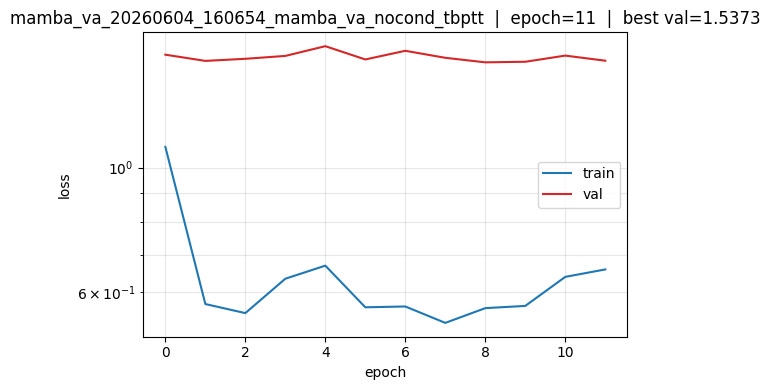

In [5]:
# ── 3. Loss curves ───────────────────────────────────────────
_ = plot_loss_curves(RUN_DIR)

In [ ]:
# ── 4. Checkpoint loading + streaming render ──────────────────────────
# CompSSM is a plain nn.Module wrapped by the Lightning `CompSSMSystem` at train
# time (weights live under the `model.` prefix in the checkpoint).  We rebuild
# the bare CompSSM from hparams.json and load the stripped state_dict — no need
# to import the Lightning system here.

def load_compssm_from_ckpt(ckpt_path: str, hparams_path: str | None = None):
    if hparams_path is None:
        hparams_path = _find_hparams_json(ckpt_path)
    assert hparams_path and os.path.isfile(hparams_path), (
        f"hparams.json not found near {ckpt_path}")
    with open(hparams_path) as f:
        hp = json.load(f)

    c = hp["compssm"]
    model = CompSSM(
        n_params=c["n_params"], d_model=c["d_model"], d_state=c["d_state"],
        n_layers=c["n_layers"], expand=c["expand"], conv_kernel=c["conv_kernel"],
        n_bands=c["n_bands"], max_db=c["max_db"],
        sr=c.get("sr", hp.get("sample_rate", 44100)),
    )

    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    sd = ckpt.get("state_dict", ckpt)
    model_sd = {k[len("model."):]: v for k, v in sd.items() if k.startswith("model.")}
    missing, unexpected = model.load_state_dict(model_sd, strict=False)
    if missing or unexpected:
        print(f"[warning] load_state_dict: {len(missing)} missing, {len(unexpected)} unexpected")
    model.to(DEVICE).eval()
    return model, hp


@torch.no_grad()
def stream_render(model, u: torch.Tensor, chunk: int = SAMPLE_RATE, parallel: bool = True):
    """Stream (1, L) dry audio through the stateful model, carrying state across
    `chunk`-sized windows.  Equivalent to a single causal pass; parallel=True
    uses the fast associative scan within each chunk."""
    u = u.to(DEVICE)
    state, outs = None, []
    for s in range(0, u.shape[-1], chunk):
        y, state = model(u[:, s:s + chunk], state=state, parallel=parallel)
        outs.append(y)
    return torch.cat(outs, dim=1)


def _load_mono(path: str, sr: int = SAMPLE_RATE) -> np.ndarray:
    x, s = sf.read(path, dtype="float32", always_2d=True)
    x = x.mean(axis=1)
    if s != sr:
        import torchaudio
        x = torchaudio.functional.resample(torch.from_numpy(x), s, sr).numpy()
    return np.ascontiguousarray(x)


print("Loader ready: load_compssm_from_ckpt(), stream_render()")

In [7]:
# ── 5. Input → output evaluation & visualisation ────────────────────────
from IPython.display import Audio, display


def _loud_start(x: np.ndarray, n: int) -> int:
    if len(x) <= n:
        return 0
    step = max(1, n // 2)
    best, bestv = 0, -1.0
    for s in range(0, len(x) - n, step):
        v = float(np.sqrt(np.mean(x[s:s + n] ** 2)))
        if v > bestv:
            bestv, best = v, s
    return best


def _esr_np(pred, target, eps=1e-8):
    return float(np.sum((target - pred) ** 2) / (np.sum(target ** 2) + eps))


@torch.no_grad()
def evaluate_io(
    ckpt_path: str,
    songs: list[str] | None = None,
    eval_seconds: float = 6.0,
    pre_roll_sec: float = 1.0,
    hparams_path: str | None = None,
):
    """Stream a loud excerpt of each (validation) song through the model and
    collect dry / target / predicted audio for comparison."""
    model, hp = load_compssm_from_ckpt(ckpt_path, hparams_path)
    sr = int(hp["sample_rate"])
    pairs = same_setting_pairs(DATA_ROOT, hp["setting"])
    val_pairs = _validation_pairs_from_training_split(pairs, hp)
    if songs is not None:
        val_pairs = [(d, w) for d, w in val_pairs if _song_from_dry_path(d) in set(songs)]
    assert val_pairs, "No validation pairs selected."

    n = int(eval_seconds * sr)
    pre = int(pre_roll_sec * sr)
    results = []
    for dry_path, wet_path in val_pairs:
        song = _song_from_dry_path(dry_path)
        dry, wet = _load_mono(dry_path, sr), _load_mono(wet_path, sr)
        L = min(len(dry), len(wet))
        dry, wet = dry[:L], wet[:L]
        start = _loud_start(dry, n)
        ctx = max(0, start - pre)
        off = start - ctx
        u = torch.from_numpy(dry[ctx:start + n]).unsqueeze(0)
        y = stream_render(model, u).squeeze(0).float().cpu().numpy()
        pred = y[off:off + n]
        results.append({
            "song": song, "start": start,
            "dry": dry[start:start + n], "target": wet[start:start + n], "pred": pred,
            "esr": _esr_np(pred, wet[start:start + n]),
        })
    return results, hp


def plot_io(results, hp, run_dir: str | None = None, title: str | None = None):
    sr = int(hp["sample_rate"])
    n = len(results[0]["dry"])
    nrows = len(results)
    fig, axes = plt.subplots(nrows, 3, figsize=(18, 3.2 * nrows), squeeze=False)
    zoom = int(0.08 * sr)        # 80 ms waveform zoom
    zoff = n // 2
    t_zoom = np.arange(zoom) / sr * 1000  # ms

    for r, res in enumerate(results):
        d, tg, pr = res["dry"], res["target"], res["pred"]

        ax = axes[r][0]
        ax.plot(t_zoom, d[zoff:zoff + zoom], color="gray", alpha=0.5, lw=0.8, label="dry in")
        ax.plot(t_zoom, tg[zoff:zoff + zoom], color="tab:green", lw=0.9, label="target out")
        ax.plot(t_zoom, pr[zoff:zoff + zoom], color="tab:orange", lw=0.9, label="pred out")
        ax.set_title(f"{res['song']} — waveform (80 ms)")
        ax.set_xlabel("ms"); ax.set_ylabel("amp")
        ax.legend(loc="upper right", fontsize=7)

        ax = axes[r][1]
        t_full = np.arange(n) / sr
        ax.plot(t_full, pr - tg, color="tab:red", lw=0.4)
        ax.set_title(f"error (pred − target) — ESR={res['esr']:.4f}")
        ax.set_xlabel("s"); ax.set_ylabel("err")
        ax.axhline(0, color="gray", lw=0.5, ls="--")

        ax = axes[r][2]
        k = slice(None, None, max(1, n // 4000))   # subsample for the scatter
        ax.scatter(d[k], pr[k], s=2, alpha=0.25, color="tab:blue", label="pred")
        ax.scatter(d[k], tg[k], s=2, alpha=0.15, color="tab:green", label="target")
        lim = float(max(np.abs(d).max(), 1e-3))
        ax.plot([-lim, lim], [-lim, lim], color="gray", lw=0.6, ls="--", label="unity")
        ax.set_title("input vs output (compression curve)")
        ax.set_xlabel("dry in"); ax.set_ylabel("out")
        ax.legend(loc="upper left", fontsize=7)

    fig.suptitle(title or f"mamba_va CompSSM — {RUN_NAME}", y=1.005)
    fig.tight_layout()
    if run_dir:
        out = os.path.join(run_dir, "eval_io_comparison.png")
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print(f"Saved plot → {out}")
    plt.show()

    print("\nPer-song ESR (lower = better):")
    for res in results:
        print(f"  {res['song']:<20s}  ESR = {res['esr']:.4f}")


def listen(results, sr: int = SAMPLE_RATE, which: int = 0):
    res = results[which]
    print(f"Listen — {res['song']}:  dry / target / predicted")
    display(Audio(res["dry"], rate=sr))
    display(Audio(res["target"], rate=sr))
    display(Audio(res["pred"], rate=sr))


print("Eval functions ready: evaluate_io(), plot_io(), listen()")

Eval functions ready: evaluate_io(), plot_io(), listen()


## Usage

Re-run the cells below any time; they read the latest synced files from Drive.
Use the available-runs cell first, then optionally set `SELECTED_RUN_NAME` in
the run-selection cell (or leave it `None` for the newest run).

Running best-009-480.ckpt
Validation split: 2 validation songs, 8 train songs (seed=42, train_split=0.8)
Validation songs: ['Borderline', 'NosPalpitants']
Saved plot → /Volumes/Saola's Drive/AllCode/thesis/data/mamba_va_runs/mamba_va_20260604_160654_mamba_va_nocond_tbptt/eval_io_comparison.png


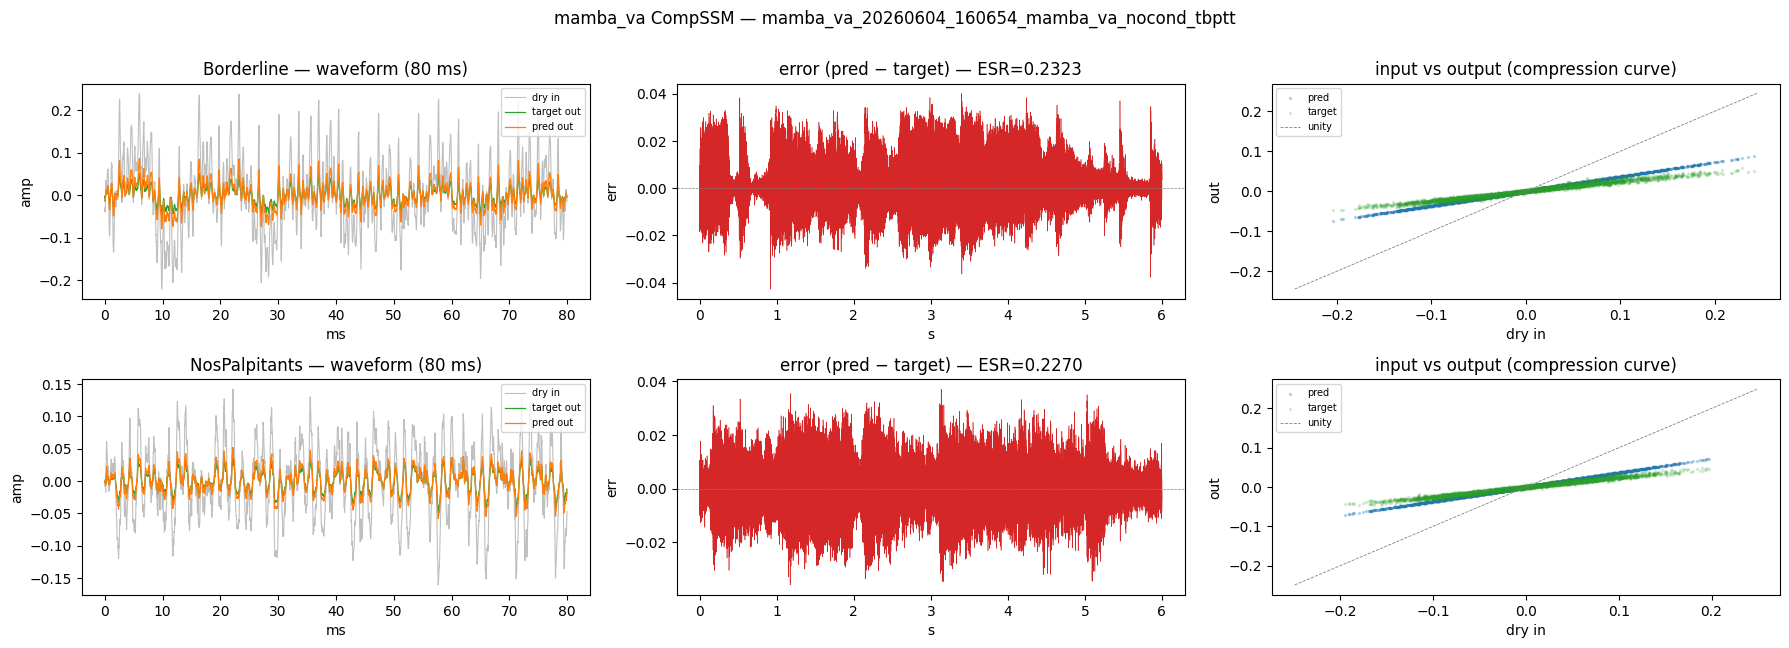


Per-song ESR (lower = better):
  Borderline            ESR = 0.2323
  NosPalpitants         ESR = 0.2270


In [8]:
# Input→output preview over the validation songs
print(f"Running {os.path.basename(EVAL_CKPT_PATH)}")

results, hp = evaluate_io(
    ckpt_path=EVAL_CKPT_PATH,
    eval_seconds=6.0,
    pre_roll_sec=1.0,
)
plot_io(results, hp, run_dir=RUN_DIR)

In [9]:
# Save excerpts to the run dir and listen to the first validation song
for res in results:
    base = os.path.join(RUN_DIR, f"eval_{res['song']}")
    sf.write(base + "_dry.wav",    res["dry"].astype(np.float32),    SAMPLE_RATE)
    sf.write(base + "_target.wav", res["target"].astype(np.float32), SAMPLE_RATE)
    sf.write(base + "_pred.wav",   res["pred"].astype(np.float32),   SAMPLE_RATE)

listen(results, which=0)

Listen — Borderline:  dry / target / predicted


In [ ]:
# ── 6. Validation audio metrics (excerpt-based, duration-weighted) ─────────
#
# Mirrors eval_lstm's audio-metrics cell, bounded to excerpts to keep the
# monitor snappy (since mamba_va v0.2 the detector is scan-parallel, so whole
# songs are feasible too — raise EXCERPT_SEC / EXCERPTS_PER_SONG for more
# coverage at proportional cost; use 'mps' for a speed-up).  Each window is
# warmed up with PRE_ROLL_SEC of context so the carried state is realistic,
# then one duration-weighted validation row is reported over the full metric
# set.
import gc

# Leave as None to use the full validation split; set a small int / list of
# song names for a quick subset.
MAX_VALIDATION_SONGS: int | None = None
EVAL_VALIDATION_SONGS: list[str] | None = None
EXCERPT_SEC        = 8.0    # length of each scored window
EXCERPTS_PER_SONG  = 3      # evenly-spaced windows per song
PRE_ROLL_SEC       = 1.0    # warm-up context streamed before each window
SAVE_CHUNK_METRICS = False

model, hp = load_compssm_from_ckpt(EVAL_CKPT_PATH, HPARAMS_PATH)
sr = int(hp["sample_rate"])
n = int(round(EXCERPT_SEC * sr))
pre = int(round(PRE_ROLL_SEC * sr))
metric_cols = ["MAE (L1)", "MSE (L2)", "ESR", "MR-STFT", "EDC", "M_NRMSE", "M_SF"]

all_pairs = same_setting_pairs(DATA_ROOT, hp["setting"])
eval_pairs = _validation_pairs_from_training_split(all_pairs, hp)
if EVAL_VALIDATION_SONGS is not None:
    sel = set(EVAL_VALIDATION_SONGS)
    eval_pairs = [(d, w) for d, w in eval_pairs if _song_from_dry_path(d) in sel]
if MAX_VALIDATION_SONGS is not None:
    eval_pairs = eval_pairs[:MAX_VALIDATION_SONGS]
assert eval_pairs, "No validation pairs selected for evaluation."

validation_chunk_rows = []
for song_idx, (dry_path, wet_path) in enumerate(eval_pairs, start=1):
    song = _song_from_dry_path(dry_path)
    dry, wet = _load_mono(dry_path, sr), _load_mono(wet_path, sr)
    L = min(len(dry), len(wet))
    dry, wet = dry[:L], wet[:L]
    starts = (np.linspace(0, L - n, EXCERPTS_PER_SONG, dtype=int)
              if L > n else np.zeros(EXCERPTS_PER_SONG, dtype=int))
    print(f"[{song_idx}/{len(eval_pairs)}] {song} "
          f"({L / sr:.1f}s) — {len(set(starts))} x {EXCERPT_SEC:.0f}s excerpts")

    for ex_idx, start in enumerate(dict.fromkeys(int(s) for s in starts), start=1):
        ctx = max(0, start - pre)
        off = start - ctx
        u = torch.from_numpy(dry[ctx:start + n]).unsqueeze(0)
        with torch.no_grad():
            y = stream_render(model, u).squeeze(0)[off:off + n].float().cpu()
        m = min(y.shape[-1], n)
        pred_chunk = y[:m]
        wet_chunk = torch.from_numpy(wet[start:start + m])
        losses = compute_audio_losses(pred_chunk.view(1, 1, -1), wet_chunk.view(1, 1, -1))
        validation_chunk_rows.append({
            "Song": song, "Excerpt": ex_idx, "Start (s)": start / sr,
            "Duration (s)": m / sr, "Frames": m, **losses,
        })
    gc.collect()

assert validation_chunk_rows, "No validation excerpts were evaluated."

weighted_metrics = _weighted_average_metric_rows(validation_chunk_rows, metric_cols)
total_frames = sum(row["Frames"] for row in validation_chunk_rows)
validation_metrics_df = pd.DataFrame([{
    "Split": "validation",
    "Songs": len(eval_pairs),
    "Excerpts": len(validation_chunk_rows),
    "Duration (s)": total_frames / sr,
    **weighted_metrics,
}])

validation_metrics_path = Path(RUN_DIR) / "eval_audio_metrics_validation.csv"
validation_metrics_df.to_csv(validation_metrics_path, index=False)
print(f"Saved validation audio metrics → {validation_metrics_path}")

if SAVE_CHUNK_METRICS:
    chunk_metrics_path = Path(RUN_DIR) / "eval_audio_metrics_validation_excerpts.csv"
    pd.DataFrame(validation_chunk_rows).to_csv(chunk_metrics_path, index=False)
    print(f"Saved per-excerpt audio metrics → {chunk_metrics_path}")

display(validation_metrics_df)